In [29]:
# importing librariees
import pandas as pd # for reading csv file and handling dataset
import numpy as np # for mathematical operations
import matplotlib.pyplot as plt # for graphical visaulization
import seaborn as sns # for statistical visualization
from sklearn.preprocessing import StandardScaler # for feature scaling
from sklearn.decomposition import PCA # for feature selection
from sklearn.cluster import KMeans, DBSCAN # for clustering
from sklearn.metrics import silhouette_score # evaluation of clustering performance

In [30]:
# Loading dataset
df = pd.read_excel(r"C:\Users\rasika\Downloads\EastWestAirlines.xlsx")
df

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0


In [31]:
# Summary of dataset
df.info() # number of data entries, number of columns and there types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [32]:
# summary Statistics
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [33]:
# Removing ID# column cause it is not that important
df.drop('ID#', axis = 1, inplace = True)

### Histogram for checking frequency distribution and skewness in data

array([[<Axes: title={'center': 'Balance'}>,
        <Axes: title={'center': 'Qual_miles'}>,
        <Axes: title={'center': 'cc1_miles'}>],
       [<Axes: title={'center': 'cc2_miles'}>,
        <Axes: title={'center': 'cc3_miles'}>,
        <Axes: title={'center': 'Bonus_miles'}>],
       [<Axes: title={'center': 'Bonus_trans'}>,
        <Axes: title={'center': 'Flight_miles_12mo'}>,
        <Axes: title={'center': 'Flight_trans_12'}>],
       [<Axes: title={'center': 'Days_since_enroll'}>,
        <Axes: title={'center': 'Award?'}>, <Axes: >]], dtype=object)

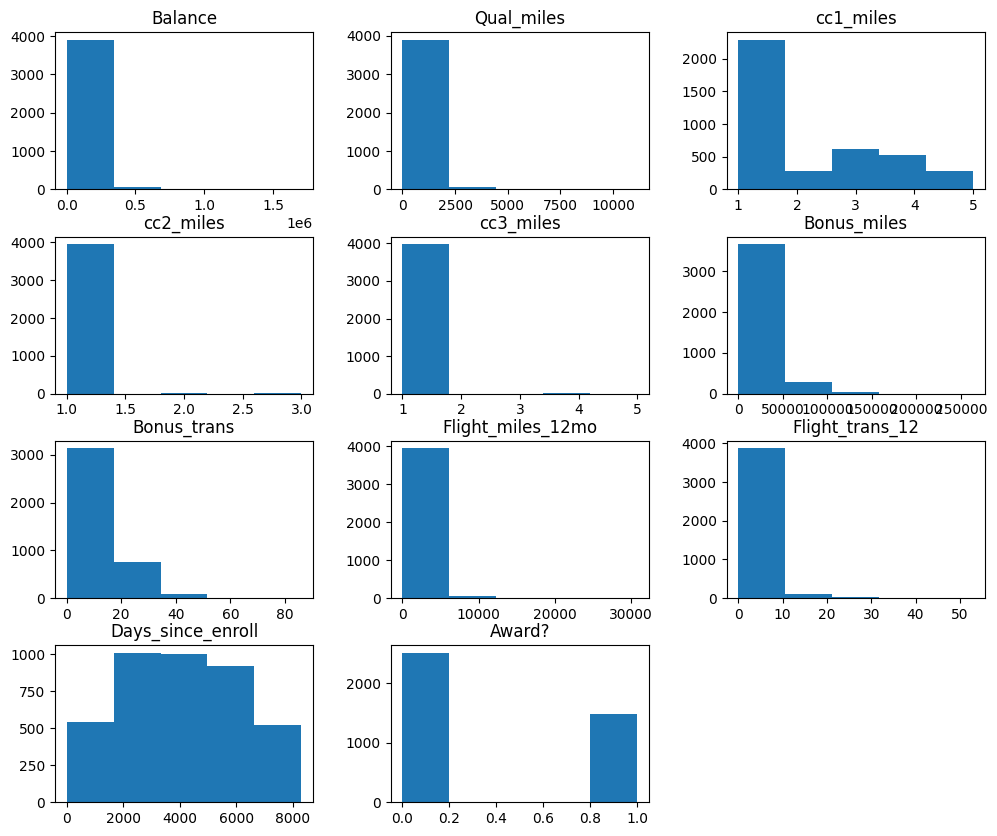

In [34]:
df.hist(bins = 5, grid = False, figsize = (12, 10))

1. All features are positively skewed with many values are very low distributed around 0.
2. Days_since enroll is approximetally bell shaped
3. In Award column people with no awards are more

### Boxplot for Outlier Detection

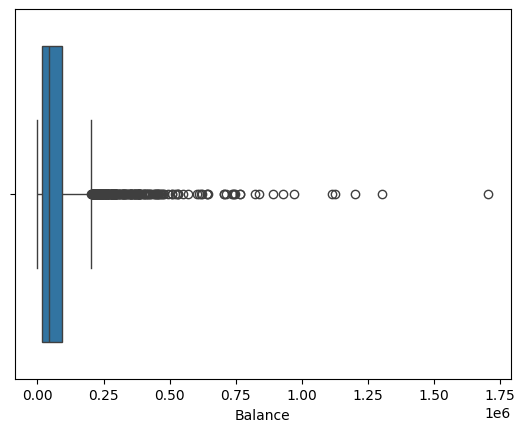

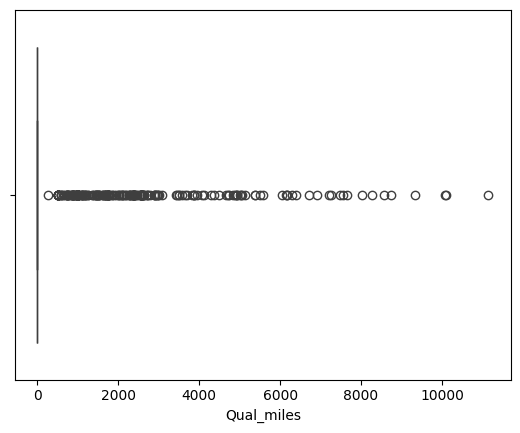

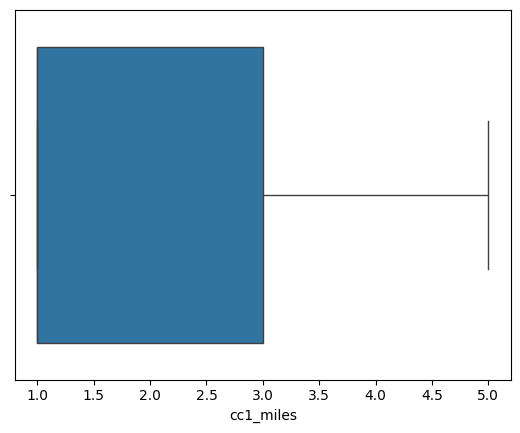

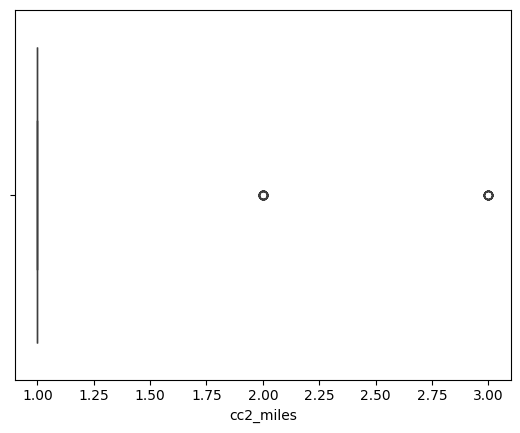

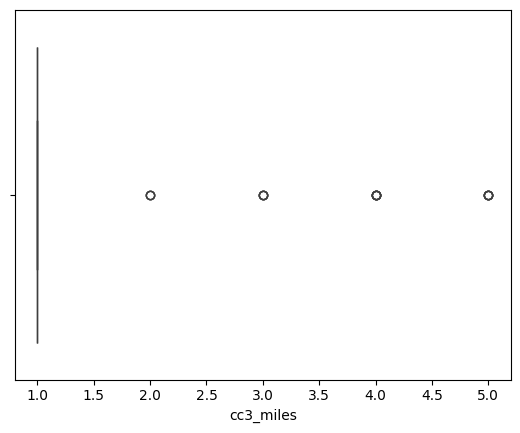

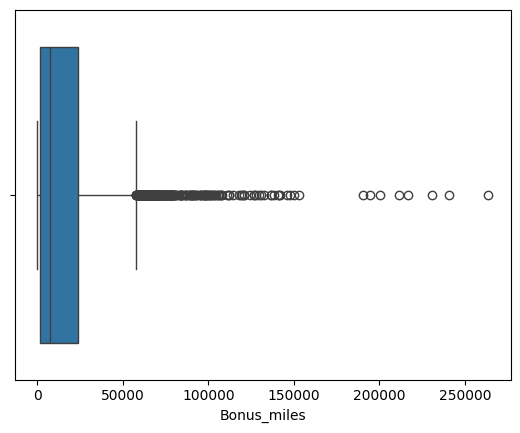

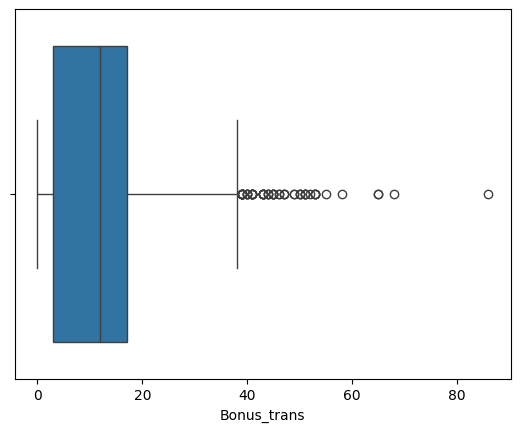

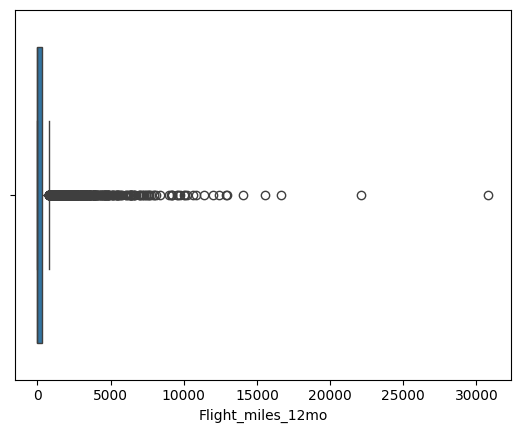

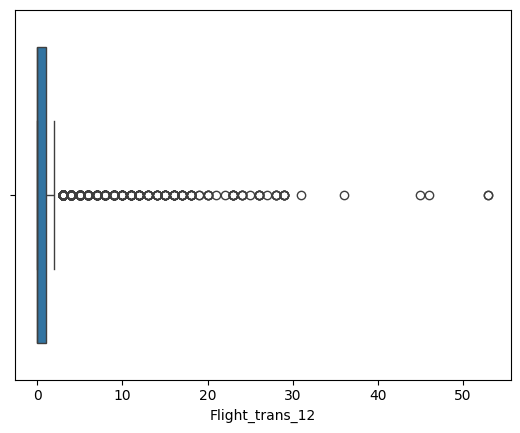

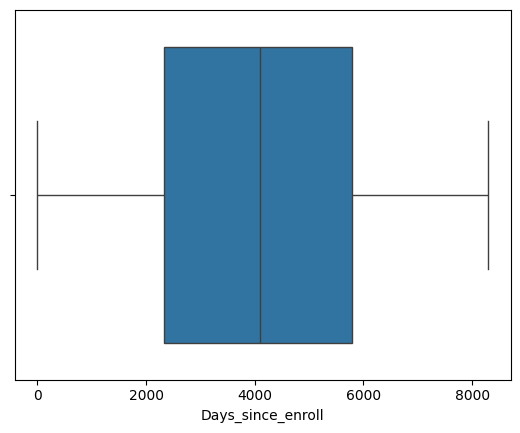

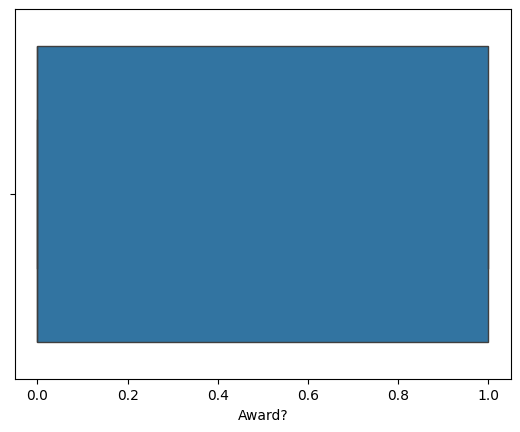

In [35]:
X = df
for column in X.columns:
    sns.boxplot(data = df, x = column)
    plt.show()

#### Outlier here need not to be removed cause they can be important to analyse customer's behavior like A customer with extremely high Balance or Bonus_miles may be a premium traveler.Removing outliers can cause to losing imporatant information to identify customer behavior

In [36]:
# Checking for missing values
df.isnull().sum()

Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [37]:
# checking for duplicates
df.duplicated().sum()

np.int64(1)

In [38]:
# removing duplicate row
df.drop_duplicates(inplace = True)

In [39]:
df.duplicated().sum()

np.int64(0)

### Heatmap to check Correlation among features

<Axes: >

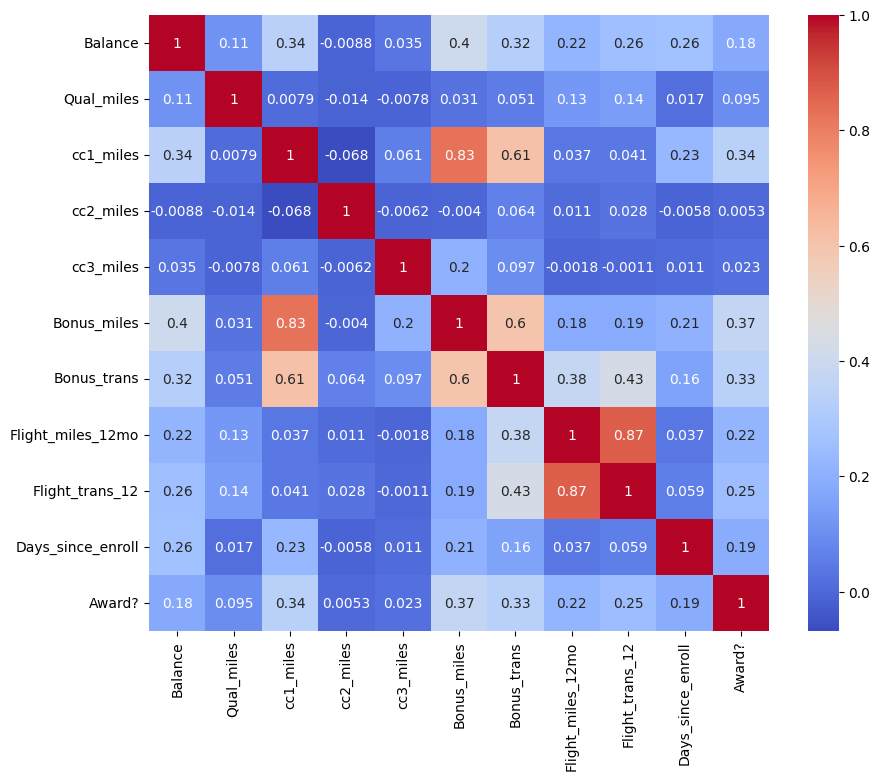

In [40]:
plt.figure(figsize = (10, 8))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')

1. cc1_miles is positively correlated with Bonus_miles
2. Flight_miles_12mo is positively correlated with Flight_trans_12

In [41]:
# Standardization 
sc = StandardScaler()
X_sc = sc.fit_transform(X)
X_sc

array([[-4.51293870e-01, -1.86322793e-01, -7.69731660e-01, ...,
        -3.62219103e-01,  1.39523468e+00, -7.67071631e-01],
       [-5.39604653e-01, -1.86322793e-01, -7.69731660e-01, ...,
        -3.62219103e-01,  1.37973643e+00, -7.67071631e-01],
       [-3.20192202e-01, -1.86322793e-01, -7.69731660e-01, ...,
        -3.62219103e-01,  1.41170157e+00, -7.67071631e-01],
       ...,
       [-2.23153612e-04, -1.86322793e-01,  6.82893866e-01, ...,
        -3.62219103e-01, -1.31599028e+00,  1.30365921e+00],
       [-1.85776026e-01, -1.86322793e-01, -7.69731660e-01, ...,
        -9.85832074e-02, -1.31647460e+00, -7.67071631e-01],
       [-7.00646048e-01, -1.86322793e-01, -7.69731660e-01, ...,
        -3.62219103e-01, -1.31792757e+00, -7.67071631e-01]],
      shape=(3998, 11))

In [42]:
# PCA to take important features
pca = PCA()
X_pca = pca.fit_transform(X_sc)
X_pca

array([[-1.46736988, -0.06697999, -0.80345045, ..., -0.3618187 ,
        -0.06296019,  0.02537506],
       [-1.45124962, -0.06354044, -0.7525517 , ..., -0.29254281,
        -0.08155945,  0.0132537 ],
       [-1.21074217, -0.13335586, -0.7654891 , ..., -0.17898737,
        -0.20449504, -0.03523168],
       ...,
       [ 0.17311675, -0.61167088,  0.4092342 , ..., -0.36642381,
         0.29781056,  0.08718952],
       [-1.69556447,  0.72665826,  0.43912866, ..., -0.4204394 ,
         0.07273495,  0.0160763 ],
       [-2.10917219,  0.40327642,  0.5082684 , ..., -0.43849569,
         0.01353845,  0.08336305]], shape=(3998, 11))

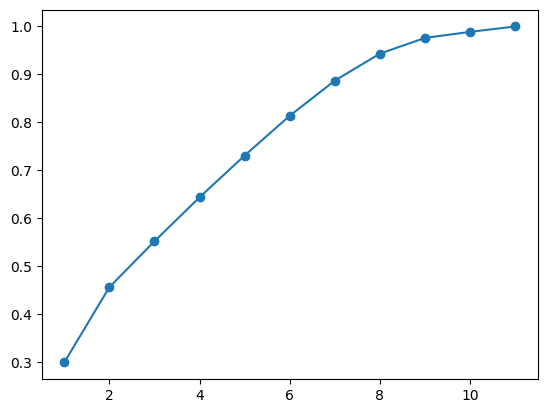

In [43]:
# Finding pc's
# Screeplot and cumulative variance that show principal components which explain variance ratio trough Elbow method
variance = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, 12),
         variance,
         marker = 'o')

#### The scree plot and cumsum shows a clear elbow at the 8th principal component, indicating that the first eight components capture most of the important information in the dataset.

In [44]:
# Fitting PCA on 4 features
pca = PCA(n_components = 8)
X_pca_final = pca.fit_transform(X_sc)
X_pca_final

array([[-1.46736988, -0.06697999, -0.80345045, ...,  1.327217  ,
         0.26855732, -0.67819071],
       [-1.45124962, -0.06354044, -0.7525517 , ...,  1.27526011,
         0.30027847, -0.75923314],
       [-1.21074217, -0.13335586, -0.7654891 , ...,  1.31027049,
         0.15959167, -0.69699124],
       ...,
       [ 0.17311675, -0.61167088,  0.4092342 , ..., -1.27122231,
         0.59844057,  1.22913074],
       [-1.69556447,  0.72665826,  0.43912866, ..., -0.26079501,
        -0.58136657,  0.56790131],
       [-2.10917219,  0.40327642,  0.5082684 , ..., -0.45941164,
        -0.3024776 ,  0.30885045]], shape=(3998, 8))

### KMeans 

In [45]:
# Finding data points far or close from their data points in their own or different cluster
wcss = []
for k in range(1, 12):
    kmeans = KMeans(
        n_clusters = k,
        random_state = 42)
    kmeans.fit_transform(X_pca_final)
    wcss.append(kmeans.inertia_)

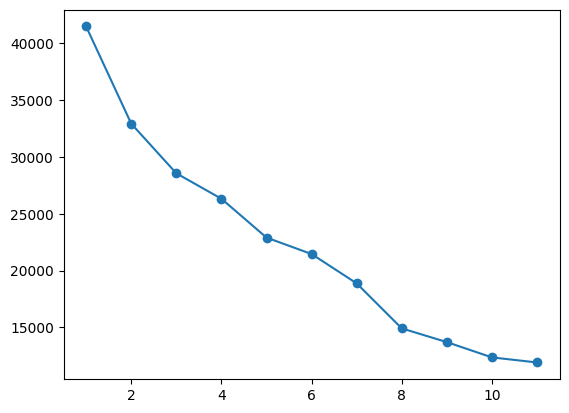

In [46]:
#Elbow plot to slect k
plt.plot(range(1, 12),
        wcss,
        marker = 'o')

In [47]:
# Kmeans with 4 clusters and model prediction
kmeans_original = KMeans(n_clusters = 4, random_state = 42)
kmeans_cluster = kmeans_original.fit_predict(X_pca_final)

In [48]:
# Experiment with Silhouette score
sil_kmeans = silhouette_score(X_pca_final, kmeans_cluster)
sil_kmeans

0.2927281673139973

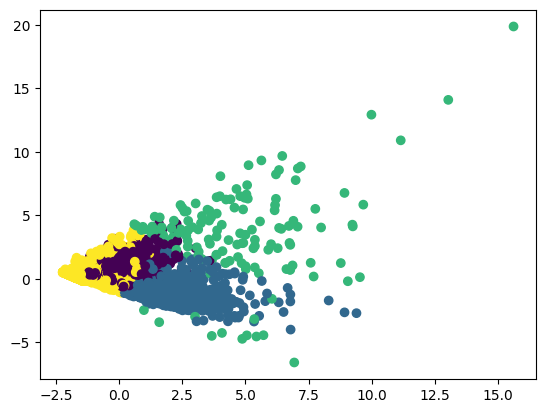

In [49]:
# sctterplot to vissualize clusters
plt.scatter(
    X_pca_final[:,0],
    X_pca_final[:, 1],
    c = kmeans_cluster)

### DBSCAN 

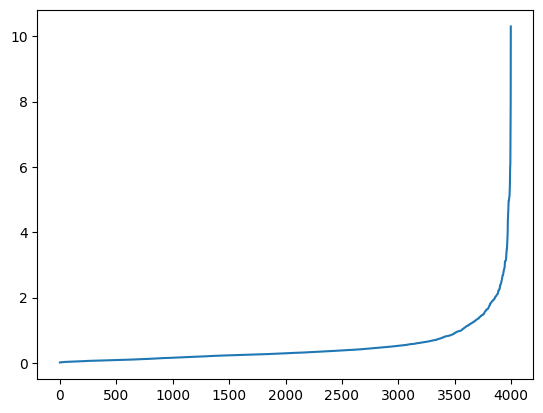

In [51]:
# to find epsilon and minimum sample
import numpy as np
from sklearn.neighbors import NearestNeighbors
neigh = NearestNeighbors(n_neighbors=7)
nbrs = neigh.fit(X_pca_final)
distances, indices = nbrs.kneighbors(X_pca_final)
distances = np.sort(distances, axis = 0)
distances = distances[:, 3]
plt.plot(distances)
plt.show()

In [52]:
# DBSCAN with measures
dbscan = DBSCAN(eps = 1, min_samples = 7)
db = dbscan.fit_predict(X_pca_final)

In [53]:
# Silhouette Score
sil_db = silhouette_score(X_pca_final, db)
sil_db

0.20965971196341607

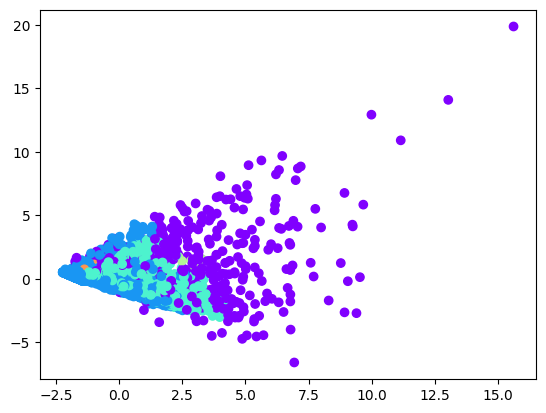

In [54]:
# Scatterplot to visualize cluster formed from dbscan
plt.scatter(X_pca_final[:,0],
    X_pca_final[:, 1],
    c = db,
    cmap = 'rainbow')

KMeans Performs better compared to DBSCAN

The cluster analysis on the East-West Airlines loyalty dataset reveals four distinct customer segments based on variables including account balance, bonus miles, flight activity and enrollment tenure.
1. Cluster 1 (dormant low-value) is the largest group. These members have low balances and minimal transaction activity despite long enrollment histories. They represent a retention challenge — enrolled but disengaged.
2. Cluster 2 (active high-flyers) is the most commercially valuable segment. Members here show high balances, high bonus miles, regular flight activity in the past 12 months, and predominantly redeem awards (Award = 1). They are the airline's core loyal base.
3. Cluster 3 (mid-tier moderate) sits between the two extremes. With moderate miles and some flight transactions, these members have growth potential and may respond to targeted incentive campaigns to move them toward Cluster 2 behavior.
4. Cluster 4 (new/emerging members) is characterized by shorter enrollment duration. Their behavior patterns are not yet fully formed, making this a critical window for the airline to build habits and loyalty early.